In [53]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [54]:
statedict = {
  "Closed" : [0.28, 0.11, 0.14, 0.06, 0.14, 0.12, 0.09, 0.06],
  "Opening" : [0.20, 0.29, 0.08, 0.13, 0.08, 0.04, 0.15, 0.03],
  "Calm" : [0.13, 0.16, 0.30, 0.11, 0.09, 0.13, 0.03, 0.05],
  "Browsing" : [0.14, 0.08, 0.14, 0.34, 0.13, 0.06, 0.10, 0.01],
  "Moderate" : [0.03, 0.01, 0.09, 0.22, 0.37, 0.10, 0.14, 0.04],
  "Busy" : [0.08, 0.05, 0.02, 0.17, 0.13, 0.29, 0.22, 0.04],
  "Crowded" : [0.06, 0.03, 0.06, 0.12, 0.12, 0.08, 0.41, 0.12],
  "Packed" : [0.13, 0.02, 0.08, 0.03, 0.05, 0.15, 0.19, 0.35]
}

In [55]:
def cycle(firstelement = "Calm", size = 400):
  global statedict
  res = [firstelement]
  for i in range(size-1):
    res.append((random.choices(list(statedict), weights=statedict[res[-1]]))[0])
  return np.array(res)

In [56]:
onecycle = cycle()

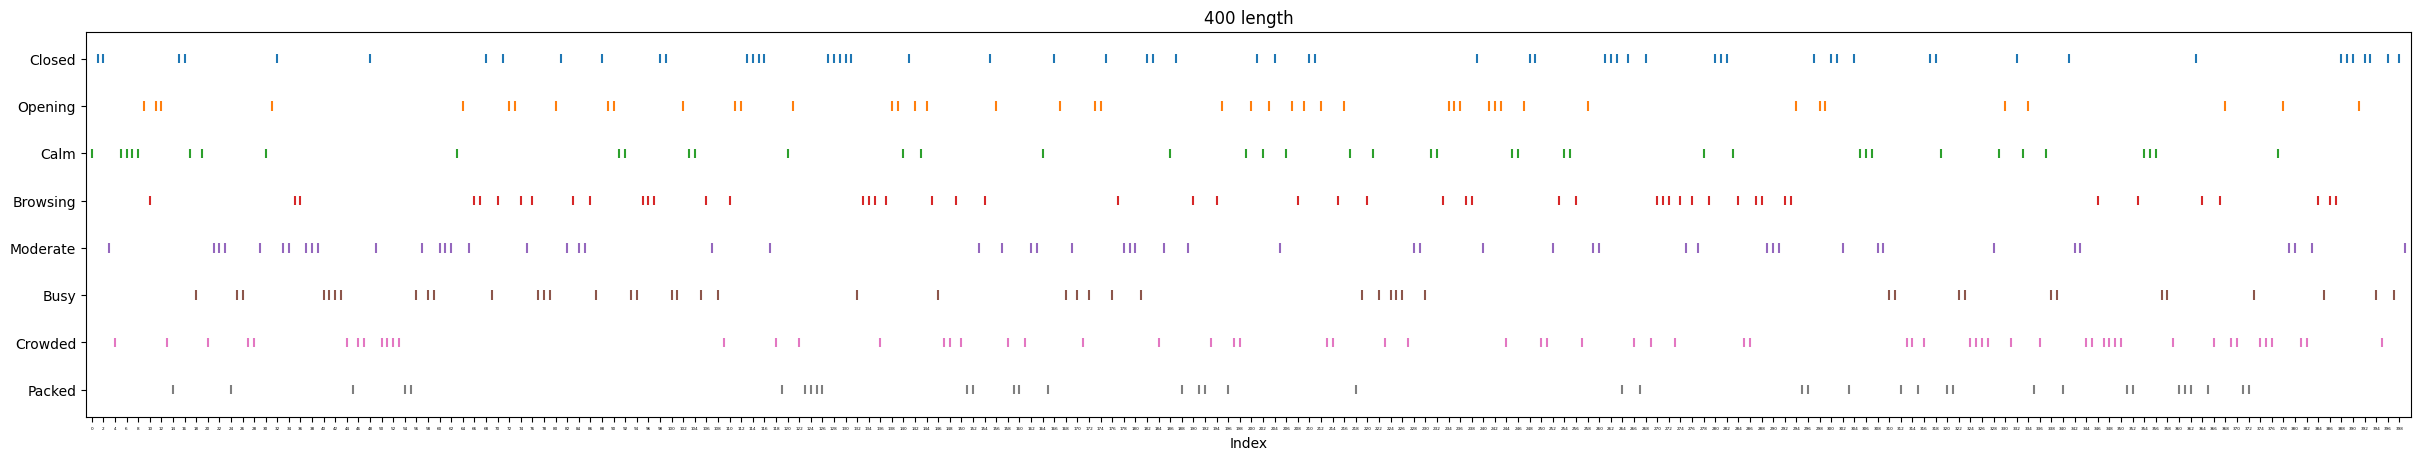

In [57]:
statelist = list(statedict.keys())
eventlist = []
for i in statelist:
  eventlist.append(np.where(onecycle == i)[0])

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(len(statelist))]
plt.subplots(figsize=(30, 5))

plt.eventplot(
  eventlist,
  colors=colors,
  lineoffsets=range(len(eventlist),0,-1),
  linelengths=0.2
)

plt.yticks(range(len(eventlist),0,-1), statelist)
plt.xlim(-1, len(onecycle))
plt.xticks(range(0, len(onecycle), 2), fontsize=3)
plt.title("400 length")
plt.xlabel("Index")
plt.show()

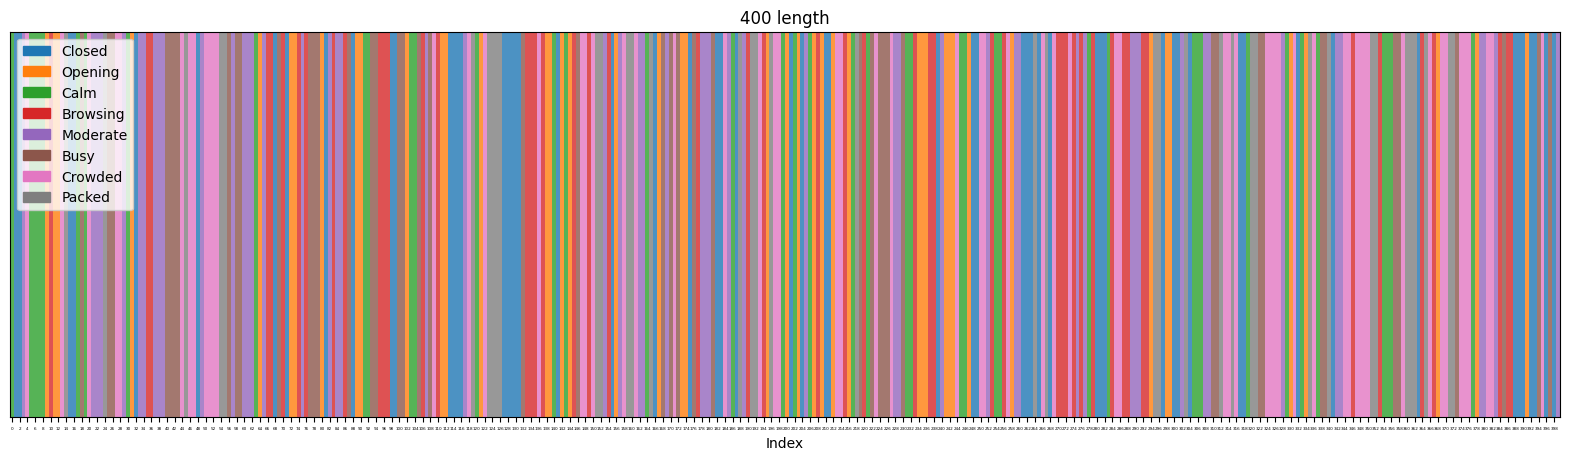

In [58]:
mapping = dict(zip(statelist, range(len(statelist))))
numeric = np.array([mapping[x] for x in onecycle])

barcode = numeric.reshape(1, -1)
plt.figure(figsize=(20, 5))
cmap = ListedColormap(colors)
plt.imshow(barcode,cmap=cmap,aspect="auto",alpha=0.8)

plt.yticks([])
plt.title("400 length")
plt.xlabel("Index")
plt.xticks(range(0, len(onecycle), 2), fontsize=3)

legend_patches = [mpatches.Patch(color=colors[i], label=statelist[i]) for i in range(len(statelist))]
plt.legend(handles=legend_patches, loc="upper left")

plt.show()


In [59]:
scount = 1600
simulation = np.array([cycle() for i in range(scount)])

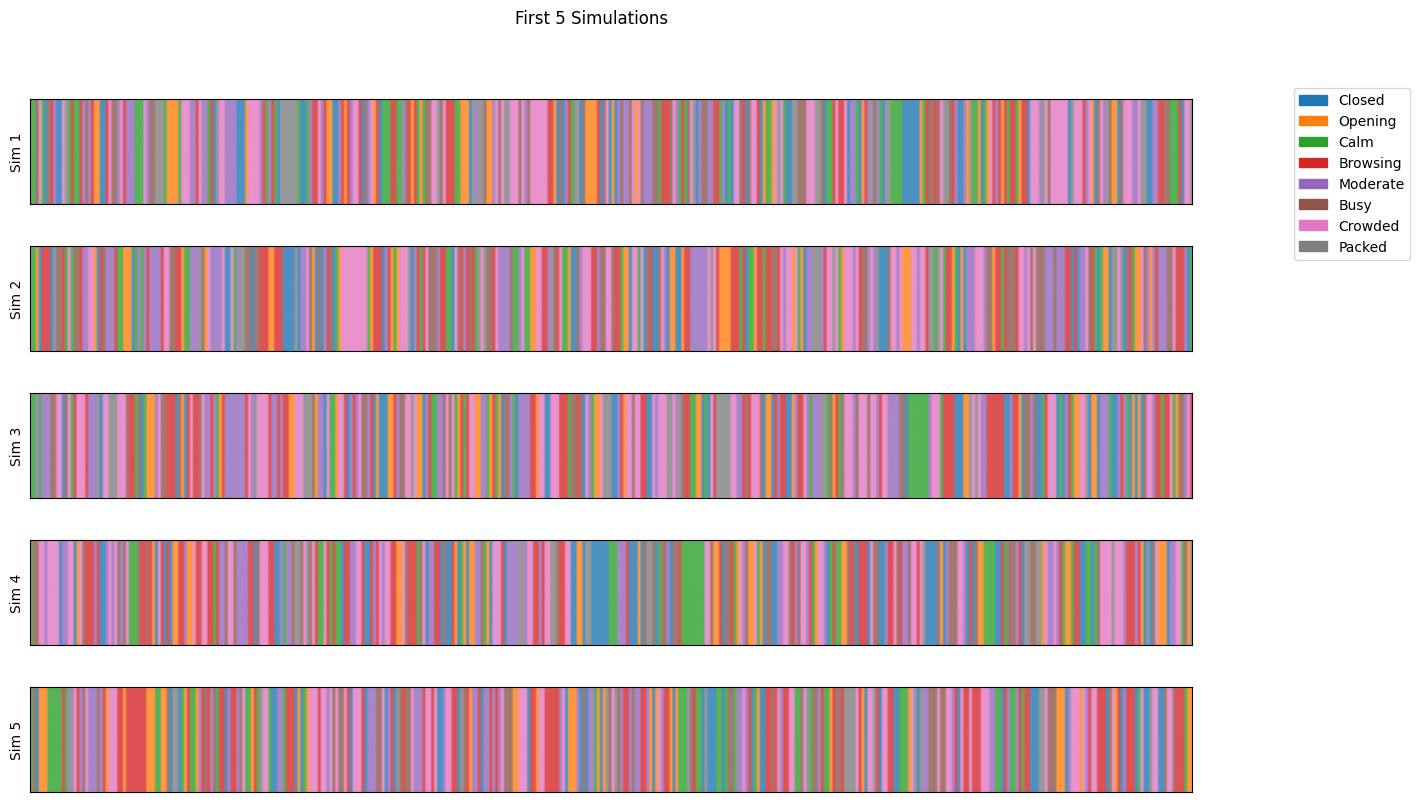

In [74]:
nsim = 5
mapping = dict(zip(statelist, range(len(statelist))))
cmap = ListedColormap(colors)
fig, axes = plt.subplots(nsim, 1, figsize=(15, 9), sharex=True)
plt.subplots_adjust(hspace=0.4)

for i in range(nsim):
  numeric_sim = np.array([mapping[state] for state in simulation[i]])
  barcode = numeric_sim.reshape(1, -1)
  axes[i].imshow(barcode, cmap=cmap, aspect="auto", alpha=0.8)
  axes[i].set_yticks([])
  axes[i].set_ylabel(f"Sim {i+1}")
  axes[i].set_xticks([])

plt.suptitle(f"First {nsim} Simulations")

legend_patches = [mpatches.Patch(color=colors[j], label=statelist[j]) for j in range(len(statelist))]
fig.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.05, 0.9))
plt.show()

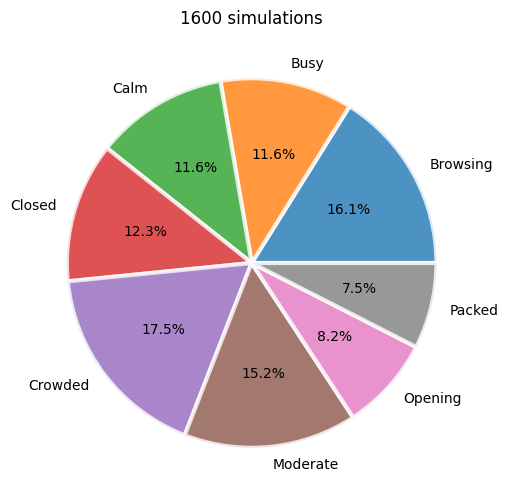

In [61]:
categories, counts = np.unique(simulation, return_counts=True)

plt.figure(figsize=(6, 6))
plt.pie(
  counts,
  labels=categories,
  autopct="%1.1f%%",
  colors=colors,
  wedgeprops={"edgecolor": "white", "linewidth": 3,"alpha":0.8}
)

plt.title(f"{scount} simulations")
plt.show()


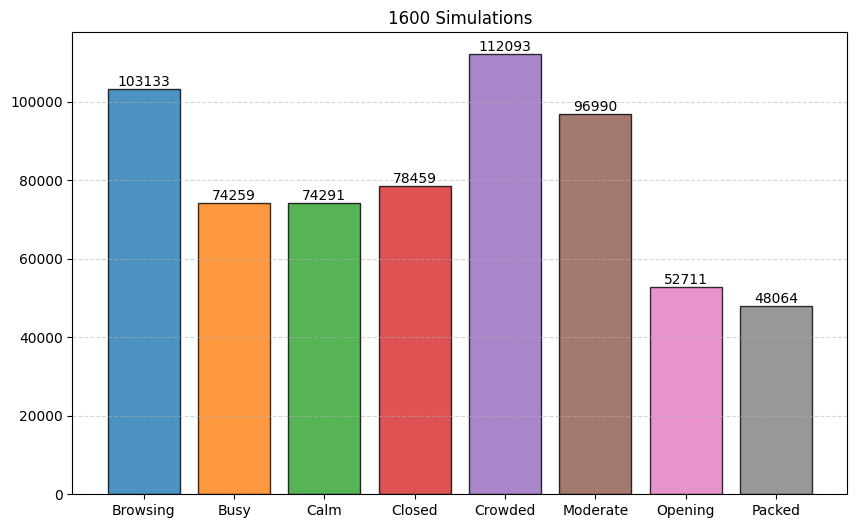

In [62]:
plt.figure(figsize=(10, 6))

bars = plt.bar(categories, counts, color=colors[:len(categories)], edgecolor="black", alpha=0.8)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.title(f"{scount} Simulations")

for bar in bars:
  height = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2., height + 5,f"{int(height)}", ha="center", va="bottom", fontsize=10)

plt.show()

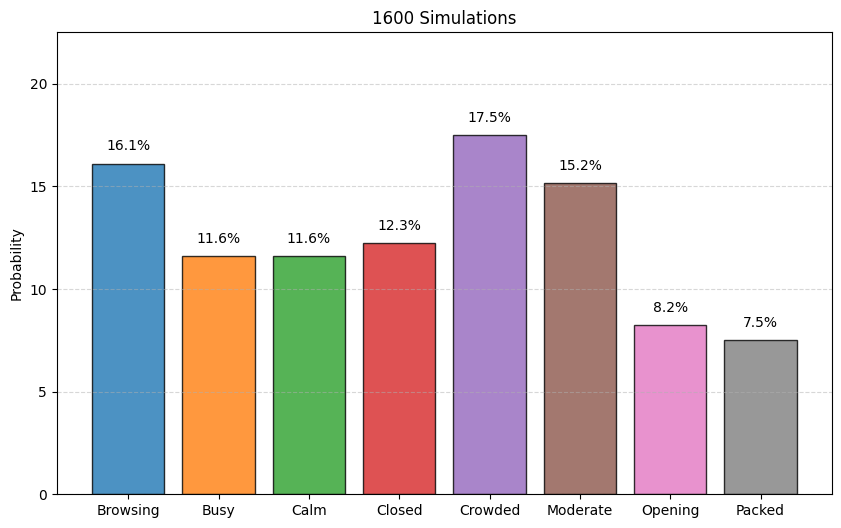

In [63]:
probabilities = counts / counts.sum()

plt.figure(figsize=(10, 6))

bars = plt.bar(categories, probabilities * 100, color=colors[:len(categories)], edgecolor='black', alpha=0.8)

for bar in bars:
  height = bar.get_height()
  plt.text(
    bar.get_x() + bar.get_width()/2.,
    height + 0.5,
    f"{height:.1f}%",
    ha="center",
    va="bottom",
    fontsize=10
  )

plt.ylim(0, max(probabilities * 100) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title(f"{scount} Simulations")
plt.ylabel("Probability")
plt.show()

In [64]:
rows = [list(statedict[state]) for state in statelist]
statematrix = np.array(rows)

In [65]:
v = np.zeros(len(statelist))
v[0] = 1
for _ in range(100):
    v = v @ statematrix
print("Iteration :: ",v)

Iteration ::  [0.12247085 0.08262714 0.11288288 0.16219084 0.15102833 0.11682455
 0.17659322 0.07538218]


In [66]:
values, vectors = np.linalg.eig(statematrix.T)
idx = np.argmin(np.abs(values - 1))
pi = vectors[:, idx].real
pi = pi / pi.sum()
print("Eigen vector :: ",pi)

Eigen vector ::  [0.12247085 0.08262714 0.11288288 0.16219084 0.15102833 0.11682455
 0.17659322 0.07538218]


In [67]:
n = len(statelist)
A = statematrix.T - np.eye(n)
A[-1] = np.ones(n)
b = np.zeros(n)
b[-1] = 1
pi = np.linalg.solve(A, b)
print("Linear system",pi)

Linear system [0.12247085 0.08262714 0.11288288 0.16219084 0.15102833 0.11682455
 0.17659322 0.07538218]


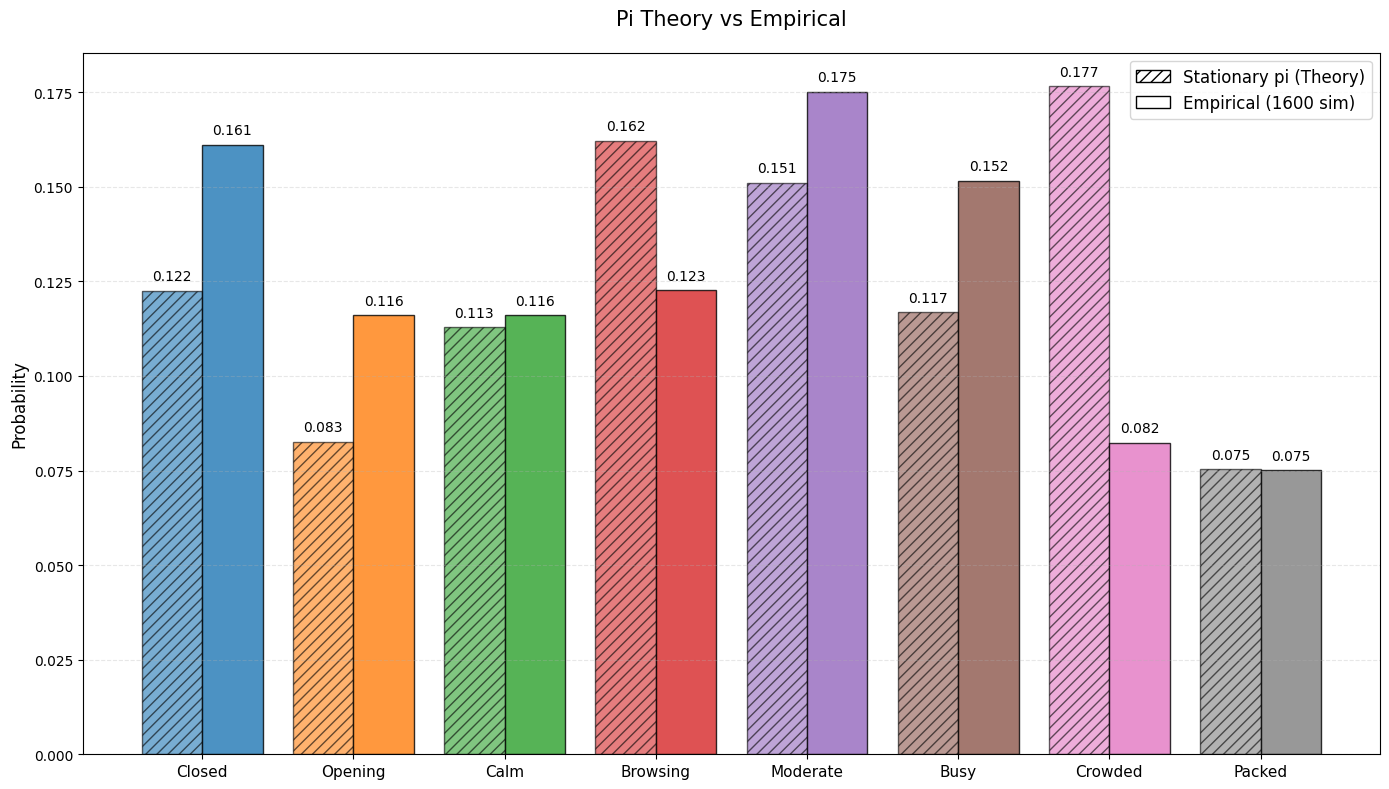

In [68]:
categories, counts = np.unique(simulation, return_counts=True)

x = np.arange(len(statelist))
width = 0.4

plt.figure(figsize=(14, 8))

for i in range(len(statelist)):
  current_color = colors[i % len(colors)]
  plt.bar(x[i] - width/2, v[i], width, color=current_color, edgecolor='black', hatch='///', alpha=0.6)
  plt.bar(x[i] + width/2, probabilities[i], width, color=current_color, edgecolor='black', alpha=0.8)

legend_elements = [
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label="Stationary pi (Theory)"),
    mpatches.Patch(facecolor='white', edgecolor='black', label=f"Empirical ({scount} sim)")
]

for i in range(len(statelist)):
  plt.text(i - width/2, v[i] + 0.002, f'{v[i]:.3f}', ha='center', va='bottom', fontsize=10)
  plt.text(i + width/2, probabilities[i] + 0.002, f'{probabilities[i]:.3f}', ha='center', va='bottom', fontsize=10)

plt.xticks(x, statelist, fontsize=11)
plt.ylabel('Probability', fontsize=12)
plt.title("Pi Theory vs Empirical", fontsize=15, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(handles=legend_elements, fontsize=12)
plt.tight_layout()
plt.show()